In [35]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple
from matplotlib.dates import date2num
from statsmodels.tsa.seasonal import seasonal_decompose
import datetime
import geopandas as gpd

from pymannkendall.pymannkendall import (
    __preprocessing,
    __missing_values_analysis,
    __mk_score,
    __variance_s,
    __z_score,
    __p_value,
    sens_slope,
)

Limitations
- The national bushfires layer did not include the major bushfire of 2003. Due to my lack of expertese in the area I would have analysed this at face value instead of realsing there was a issue with the underlying data. This meant I could not fully rely on the layer to be able to communicate the 'why'.

- 

Detected 4 abrupt change points in WATER residuals.


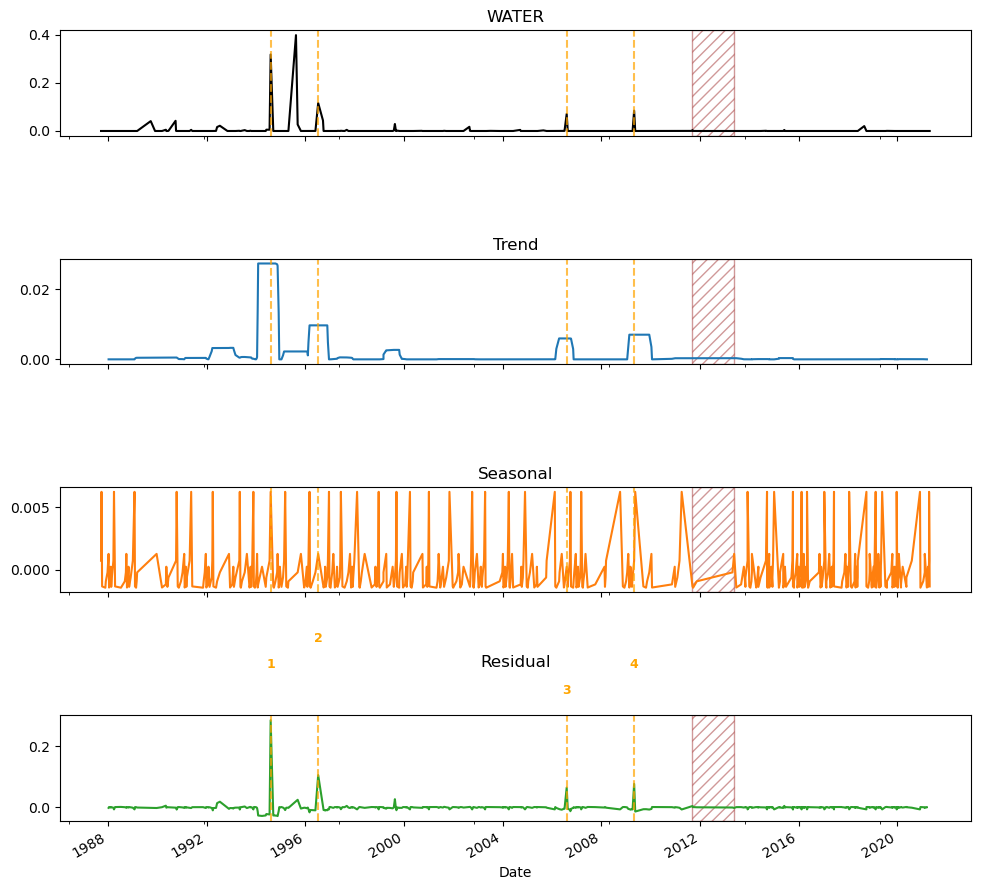

In [4]:
csv_path = "178.csv"
component = "WATER"    #  CHANGE THIS to the component you want to analyze (e.g. "PV", "GV", "NPV" "WET", "WATER")

# Load and prepare data 
df = pd.read_csv(csv_path)
df["TIME"] = pd.to_datetime(df["TIME"])
df = df.sort_values("TIME").reset_index(drop=True)

# Function: Mark low-quality data periods 
def generate_low_quality_data_periods(df):
    df = df.copy()
    df["off_value"] = 0

    # Landsat 5–8 SLC-off gap
    LS5_8_gap_start = datetime.datetime(2011, 11, 1)
    LS5_8_gap_end = datetime.datetime(2013, 4, 1)
    df.loc[
        (df["TIME"] >= LS5_8_gap_start) & (df["TIME"] <= LS5_8_gap_end),
        "off_value",
    ] = 100

    # Low observation density (less than 4 in 365 days)
    for i in range(3, len(df) - 3):
        if (df.loc[i + 3, "TIME"] - df.loc[i, "TIME"]).days > 365:
            df.loc[
                (df["TIME"] >= df.loc[i, "TIME"])
                & (df["TIME"] <= df.loc[i + 3, "TIME"]),
                "off_value",
            ] = 100
    return df

# Add low-quality flags
df = generate_low_quality_data_periods(df)

#  Extract selected component 
if component not in df.columns:
    raise ValueError(f"Component '{component}' not found in CSV columns: {list(df.columns)}")

pv = df.set_index("TIME")[component].astype(float)

# Identify low-quality data ranges 
low_quality_ranges = []
mask = df["off_value"] == 100
if mask.any():
    grouped = (mask != mask.shift()).cumsum()
    for _, group in df[mask].groupby(grouped):
        start, end = group["TIME"].iloc[0], group["TIME"].iloc[-1]
        low_quality_ranges.append((start, end))

#  Filter large gaps 
gaps = pv.index.to_series().diff().dt.days
pv_filtered = pv.loc[gaps.fillna(1) < 60]

#  Skip if too few points 
if len(pv_filtered) < 24:
    print(f"Not enough data for {component}, skipping.")
else:
    result = seasonal_decompose(pv_filtered, model="additive", period=12)
    trend, seasonal, resid = result.trend, result.seasonal, result.resid

    # Detect abrupt changes 
    threshold = 2 * resid.std() #2 standard diviations form the mean
    change_points = resid[abs(resid) > threshold].index
    print(f"Detected {len(change_points)} abrupt change points in {component} residuals.")

    # Plot 
    fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
    pv.plot(ax=axes[0], title=f"{component}", color="black")
    trend.plot(ax=axes[1], title="Trend", color="tab:blue")
    seasonal.plot(ax=axes[2], title="Seasonal", color="tab:orange")
    resid.plot(ax=axes[3], color="tab:green")
    axes[3].set_title("Residual", pad=35)

    # Shade low-quality data
    for ax in axes:
        for start, end in low_quality_ranges:
            ax.axvspan(start, end, facecolor="none", edgecolor="darkred", hatch="///", alpha=0.4)

    # Mark change points
    change_points_sorted = sorted(change_points)
    for idx, cp in enumerate(change_points_sorted, start=1):
        for ax in axes:
            ax.axvline(cp, color="orange", linestyle="--", alpha=0.7)

        # Alternate label positions
        mod = idx % 3
        y_pos = resid.max() * (1.3 + 0.3 * mod)
        axes[3].text(
            cp,
            y_pos,
            str(idx),
            color="orange",
            fontsize=9,
            fontweight="bold",
            ha="center",
            rotation=0,
            clip_on=False,
        )

    axes[-1].set_xlabel("Date")
    plt.tight_layout()
    plt.show()

In [5]:
def mk_with_slopes(y, alpha=0.05):
    """
    This function checks the Mann-Kendall (MK) test (Mann 1945, Kendall 1975, Gilbert 1987).
    Modified from pymannkendall to return fewer statistics.
    """
    res = namedtuple('Mann_Kendall_Test', ['p', 'slope', 'intercept'])
    x, c = __preprocessing(y)
    x, n = __missing_values_analysis(x, method='skip')
    
    s = __mk_score(x, n)
    var_s = __variance_s(x, n)
    z = __z_score(s, var_s)
    p, h, trend = __p_value(z, alpha)
    slope, intercept = sens_slope(y)
    return res(p, slope, intercept)

# === Run Mann-Kendall on selected component ===
p, slope, intercept = mk_with_slopes(df[component])

# === Plot ===
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

# Theil–Sen line
y = np.arange(len(df[component])) * slope + intercept
ax.plot(date2num(df["TIME"]), y, color='tab:red', label='Theil–Sen slope')

# Component time series
df.plot(x="TIME", y=component, ax=ax, label=component, color="black")

ax.set_ylabel(component)
ax.set_xlabel(None)
ax.grid(alpha=0.5)

# Annotate slope and p-value
textstr = f"Slope: {slope*12:.4f}/yr\np-value: {p:.4f}"
ax.text(
    0.82, 0.16, textstr,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.8)
)

ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

NameError: name '__preprocessing' is not defined